# **Clasificador de imágenes: Modelo 4.1**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026

### **CAMBIOS RESPECTO AL MODELO ANTERIOR**

En esta versión decidimos mantener el scheduler ReduceLROnPlateau, ya que en pruebas anteriores ayudaba a estabilizar el aprendizaje. La principal diferencia respecto al modelo previo es la incorporación de un modelo preentrenado, concretamente ResNet18, modificando únicamente su última capa para adaptarla a nuestras seis clases.


### **RESULTADOS OBTENIDOS**

El modelo alcanzó un 63% de accuracy en el conjunto de test, una mejora previsible frente a modelos anteriores gracias al uso de transfer learning. Aun así, creemos que ResNet18 no es necesariamente la mejor opción para este dataset, ya que las piezas de ajedrez requieren capturar detalles finos y patrones pequeños, y este modelo puede quedarse corto en ese sentido. Modelos un poco más profundos, como ResNet50, parecen reconocer mejor esas variaciones incluso con pocos datos.


Saving dataset4.zip to dataset4 (1).zip
Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Epoch [1/20] - Train Loss: 1.7467, Train Acc: 27.69% | Val Loss: 1.6827, Val Acc: 36.92%
Epoch [2/20] - Train Loss: 1.4622, Train Acc: 46.59% | Val Loss: 1.3273, Val Acc: 52.31%
Epoch [3/20] - Train Loss: 1.2160, Train Acc: 58.02% | Val Loss: 1.3027, Val Acc: 47.69%
Epoch [4/20] - Train Loss: 1.1290, Train Acc: 61.54% | Val Loss: 1.0845, Val Acc: 58.46%
Epoch [5/20] - Train Loss: 0.9781, Train Acc: 70.11% | Val Loss: 0.9721, Val Acc: 63.08%
Epoch [6/20] - Train Loss: 0.9107, Train Acc: 75.38% | Val Loss: 0.9861, Val Acc: 63.08%
Epoch [7/20] - Train Loss: 0.8931, Train Acc: 74.73% | Val Loss: 0.9605, Val Acc: 64.62%
Epoch [8/20] - Train Loss: 0.8561, Train Acc: 73.19% | Val Loss: 0.9804, Val Acc: 60.00%
Epoch [9/20] - Train Loss: 0.8266, Train Acc: 77.80% | Val Loss: 0.9100, Val Acc: 64.62%
Epoch [10/20] - Train Loss: 0.7

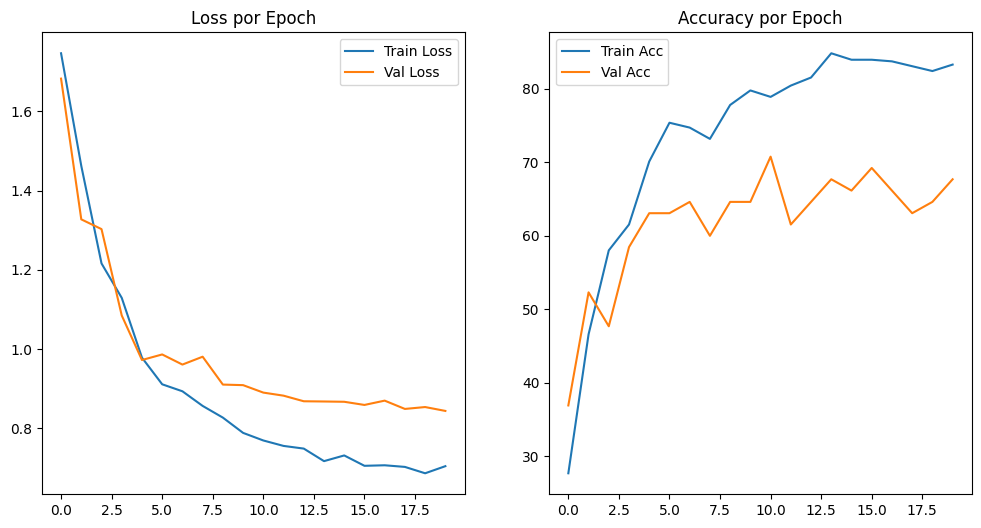

Accuracy del modelo en test: 63.36%


<Figure size 800x600 with 0 Axes>

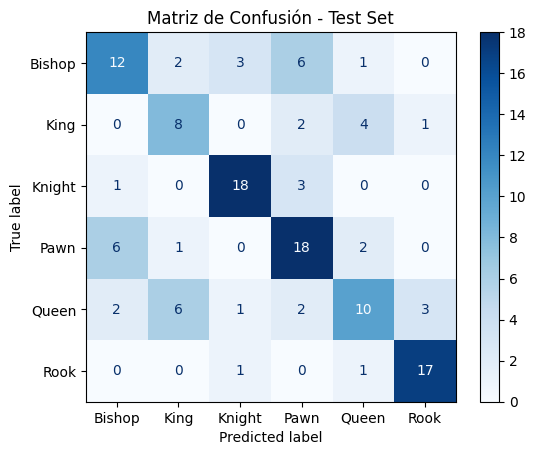

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files

import random
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

# =============================
# SUBIR Y EXTRAER DATASET
# =============================
uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES
# =============================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = val_transform

# =============================
# DATASETS
# =============================
full_dataset = datasets.ImageFolder(root="dataset4/dataset4")

train_size = int(0.7 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size])

train_data = Subset(full_dataset, train_subset.indices)
train_data.dataset.transform = train_transform

val_data = Subset(full_dataset, val_subset.indices)
val_data.dataset.transform = val_transform

test_data = Subset(full_dataset, test_subset.indices)
test_data.dataset.transform = test_transform

# =============================
# DATALOADERS
# =============================
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Total imágenes: {len(full_dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {full_dataset.classes}")

# =============================
# MODELO PREENTRENADO (ResNet18)
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargamos ResNet18 con pesos preentrenados modernos
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Congelamos todas las capas excepto la última
for param in model.parameters():
    param.requires_grad = False

# Reemplazamos la última capa fully connected
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)
model = model.to(device)

# =============================
# CRITERIO, OPTIMIZADOR Y SCHEDULER
# =============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',factor=0.5, patience=3)

# =============================
# ENTRENAMIENTO
# =============================
epochs = 20
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    val_acc_float = float(val_acc)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# =============================
# GRAFICAS DE PROGRESO
# =============================
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# EVALUACIÓN FINAL EN TEST
# =============================
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy del modelo en test: {100 * correct / total:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()
